# BSD10k Confidence Regression Linear Model

목표: VS Code/Jupyter에서 로컬 `data` 폴더의 BSD10k `CLAP audio embedding`, `CLAP text embedding`, `class_idx one-hot(23)`을 사용해 `confidence(1~5)`를 regression으로 예측합니다.

confidence는 audio/text와 class label의 매핑 신뢰도를 나타내므로, 모든 입력 조합은 class one-hot을 함께 사용합니다.

실험 구성:

- A: Audio + Class one-hot
- B: Text + Class one-hot
- C: Audio + Text + Class one-hot

모델 구성:

- Dropout
- Linear 1개

평가 지표:

- MAE
- MSE
- 반올림 Accuracy
- 반올림 예측값 기준 Confusion Matrix

In [1]:
# =========================
# 0. VS Code 로컬 실행 안내
# =========================
# Google Drive 마운트는 사용하지 않습니다.
# 이 노트북은 현재 작업 폴더 또는 상위 폴더에서 data/metadata/BSD10k_metadata.csv를 찾아 실행됩니다.

In [2]:
# =========================
# 1. 경로 설정
# =========================
from pathlib import Path

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "metadata" / "BSD10k_metadata.csv").exists():
            return candidate
    raise FileNotFoundError(
        "data/metadata/BSD10k_metadata.csv를 찾지 못했습니다. "
        "VS Code에서 Dcase baseline 폴더를 작업 폴더로 열었는지 확인하세요."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

METADATA_CSV = str(DATA_DIR / "metadata" / "BSD10k_metadata.csv")
AUDIO_EMB_DIR = str(DATA_DIR / "features" / "clap_audio_embeddings")
TEXT_EMB_DIR = str(DATA_DIR / "features" / "clap_text_embeddings")
OUTPUT_DIR = str(PROJECT_ROOT / "outputs" / "confidence_regression_outputs")

# 실험 설정
RANDOM_SEED = 42
TEST_SIZE = 0.2
BATCH_SIZE = 128
EPOCHS = 60
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 10
DROPOUT_VALUES = [0.8, 0.7, 0.6, 0.5]
DROPOUT = DROPOUT_VALUES[0]
NUM_WORKERS = 0  # Windows/VS Code 노트북에서는 0이 가장 안정적입니다.

print("PROJECT_ROOT:", PROJECT_ROOT)
print("METADATA_CSV:", METADATA_CSV)
print("AUDIO_EMB_DIR:", AUDIO_EMB_DIR)
print("TEXT_EMB_DIR:", TEXT_EMB_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: c:\Users\solok\Desktop\Dcase baseline
METADATA_CSV: c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv
AUDIO_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings
TEXT_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings
OUTPUT_DIR: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_regression_outputs


In [3]:
# =========================
# 2. 라이브러리 import
# =========================
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

DEVICE: cuda
GPU: NVIDIA GeForce RTX 3060


In [4]:
# =========================
# 3. metadata 확인
# =========================
df = pd.read_csv(METADATA_CSV)
print('metadata shape:', df.shape)
print('columns:', df.columns.tolist())
display(df.head())

required_cols = ['sound_id', 'class_idx', 'confidence']
for c in required_cols:
    assert c in df.columns, f'Missing column: {c}'

print('confidence distribution:')
print(df['confidence'].value_counts(dropna=False).sort_index())

print('class_idx unique count:', df['class_idx'].nunique())
print('class_idx examples:', sorted(df['class_idx'].dropna().unique())[:10])


metadata shape: (10956, 10)
columns: ['sound_id', 'class', 'class_idx', 'class_top', 'confidence', 'uploader', 'license', 'title', 'tags', 'description']


,sound_id,class,class_idx,class_top,confidence,uploader,license,title,tags,description
0,185755,fx-o,11,fx,4,marcgp13,http://creativecommons.org/licenses/by/3.0/,microwave_oven.wav,"campus-upf,UPF-CS13,microwave,heat,bell,noise","A microwave oven operating, including the soun..."
1,358405,is-w,5,is,5,MTG,http://creativecommons.org/licenses/by/3.0/,Sax Alto - F5,"good-sounds,single-note,multisample,sax,neuman...",Recorded in the context of the good-sounds.org...
2,358760,is-w,5,is,4,MTG,http://creativecommons.org/licenses/by/3.0/,Sax Alto - G# Major,"good-sounds,sax,neumann-U87,GsharpMajor,scale,...",Recorded in the context of the good-sounds.org...
3,432206,fx-o,11,fx,4,curesforbrokenhearts,http://creativecommons.org/publicdomain/zero/1.0/,EGG SHAKER,"egg-shaker,shaker,percussion",Large plastic egg shaker
4,80630,sp-s,8,sp,5,tim.kahn,https://creativecommons.org/licenses/by/4.0/,mechanics.wav,"american,english,female,fight,speak,talk,text,...","A request for the user ""asexton"", my girlfrien..."


confidence distribution:
confidence
1     106
2     749
3    3280
4    6045
5     776
Name: count, dtype: int64
class_idx unique count: 23
class_idx examples: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [5]:
# =========================
# 4. embedding 파일 로드 함수
# =========================
def find_npy_file(folder, sound_id):
    """sound_id.npy 파일을 찾습니다. sound_id가 int/str이어도 대응합니다."""
    folder = Path(folder)
    sid = str(sound_id)
    path = folder / f'{sid}.npy'
    if path.exists():
        return path
    # 혹시 sound_id가 185755.0 같은 형태로 들어온 경우 대비
    try:
        sid2 = str(int(float(sound_id)))
        path = folder / f'{sid2}.npy'
        if path.exists():
            return path
    except Exception:
        pass
    return None


def load_embedding_pair_rows(df, audio_dir, text_dir):
    rows = []
    audio_list = []
    text_list = []
    missing_audio = 0
    missing_text = 0
    failed = 0

    for _, row in df.iterrows():
        sid = row['sound_id']
        a_path = find_npy_file(audio_dir, sid)
        t_path = find_npy_file(text_dir, sid)

        if a_path is None:
            missing_audio += 1
            continue
        if t_path is None:
            missing_text += 1
            continue

        try:
            a = np.load(a_path).astype(np.float32).reshape(-1)
            t = np.load(t_path).astype(np.float32).reshape(-1)
        except Exception as e:
            failed += 1
            continue

        rows.append(row)
        audio_list.append(a)
        text_list.append(t)

    used_df = pd.DataFrame(rows).reset_index(drop=True)
    audio_emb = np.stack(audio_list)
    text_emb = np.stack(text_list)

    print('사용 샘플 수:', len(used_df))
    print('audio embedding shape:', audio_emb.shape)
    print('text embedding shape:', text_emb.shape)
    print('missing_audio:', missing_audio, 'missing_text:', missing_text, 'failed:', failed)

    return used_df, audio_emb, text_emb


In [6]:
import os
import glob
from pathlib import Path

print("AUDIO_EMB_DIR exists:", os.path.exists(AUDIO_EMB_DIR))
print("TEXT_EMB_DIR exists:", os.path.exists(TEXT_EMB_DIR))

print("\nAudio dir sample:")
print(glob.glob(str(Path(AUDIO_EMB_DIR) / "*"))[:10])

print("\nText dir sample:")
print(glob.glob(str(Path(TEXT_EMB_DIR) / "*"))[:10])

print("\nmetadata sound_id sample:")
print(df["sound_id"].head(10).tolist())

print("\nsound_id dtype:")
print(df["sound_id"].dtype)

AUDIO_EMB_DIR exists: True
TEXT_EMB_DIR exists: True

Audio dir sample:
['c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100007.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100029.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100253.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100279.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100347.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100360.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100426.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100457.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\clap_audio_embeddings\\100632.npy', 'c:\\Users\\solok\\Desktop\\Dcase baseline\\data\\features\\cla

In [7]:
# =========================
# 4-1. 로컬 feature 사용
# =========================
# Colab 전용 Drive 복사 단계는 제거했습니다.
# VS Code에서는 PROJECT_ROOT/data 아래 embedding을 직접 사용합니다.

assert Path(AUDIO_EMB_DIR).exists(), f"AUDIO_EMB_DIR not found: {AUDIO_EMB_DIR}"
assert Path(TEXT_EMB_DIR).exists(), f"TEXT_EMB_DIR not found: {TEXT_EMB_DIR}"
print("Using local audio embeddings:", AUDIO_EMB_DIR)
print("Using local text embeddings:", TEXT_EMB_DIR)

Using local audio embeddings: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings
Using local text embeddings: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings


In [8]:
# =========================
# 5. embedding 로드
# =========================
used_df, audio_emb, text_emb = load_embedding_pair_rows(df, AUDIO_EMB_DIR, TEXT_EMB_DIR)

# confidence target
y = used_df['confidence'].astype(float).values.astype(np.float32)

# class_idx는 101, 203, 401 같은 코드이므로 0~22로 다시 인코딩 후 one-hot 생성
label_encoder = LabelEncoder()
class_encoded = label_encoder.fit_transform(used_df['class_idx'].astype(str))
num_classes = len(label_encoder.classes_)
print('num_classes:', num_classes)
print('encoded classes:', label_encoder.classes_)

assert num_classes <= 23, f'class 수가 23개보다 큽니다: {num_classes}'

class_onehot = np.eye(num_classes, dtype=np.float32)[class_encoded]

# class가 23개보다 적게 잡힌 경우에도 항상 23차원으로 맞춤
if class_onehot.shape[1] < 23:
    padded = np.zeros((class_onehot.shape[0], 23), dtype=np.float32)
    padded[:, :class_onehot.shape[1]] = class_onehot
    class_onehot = padded
elif class_onehot.shape[1] > 23:
    raise ValueError(f'class_onehot dimension이 23을 초과했습니다: {class_onehot.shape[1]}')

print('class_onehot shape:', class_onehot.shape)

print('target y shape:', y.shape)
print('target distribution:')
print(pd.Series(y).value_counts().sort_index())

사용 샘플 수: 10956
audio embedding shape: (10956, 512)
text embedding shape: (10956, 512)
missing_audio: 0 missing_text: 0 failed: 0
num_classes: 23
encoded classes: ['0' '1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '2' '20' '21'
 '22' '3' '4' '5' '6' '7' '8' '9']
class_onehot shape: (10956, 23)
target y shape: (10956,)
target distribution:
1.0     106
2.0     749
3.0    3280
4.0    6045
5.0     776
Name: count, dtype: int64


In [9]:
# =========================
# 6. 실험 feature 구성
# =========================
# confidence는 audio/text와 class label의 매핑 신뢰도이므로 class 정보를 항상 함께 넣습니다.
features = {
    'A_audio_class': np.concatenate([audio_emb, class_onehot], axis=1),
    'B_text_class': np.concatenate([text_emb, class_onehot], axis=1),
    'C_audio_text_class': np.concatenate([audio_emb, text_emb, class_onehot], axis=1),
}

for name, X in features.items():
    print(name, X.shape)

A_audio_class (10956, 535)
B_text_class (10956, 535)
C_audio_text_class (10956, 1047)


In [10]:
# =========================
# 7. Dataset / Model 정의
# =========================
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class ConfidenceRegressor(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

In [11]:
# =========================
# 8. 평가 함수
# =========================
def regression_metrics(y_true, y_pred):
    # regression output을 1~5로 제한
    y_pred_clipped = np.clip(y_pred, 1, 5)

    mae = mean_absolute_error(y_true, y_pred_clipped)
    mse = mean_squared_error(y_true, y_pred_clipped)

    # accuracy: 반올림 후 1~5 clip
    y_pred_round = np.rint(y_pred_clipped).astype(int)
    y_pred_round = np.clip(y_pred_round, 1, 5)
    y_true_int = y_true.astype(int)
    acc = accuracy_score(y_true_int, y_pred_round)

    return {
        'MAE': mae,
        'MSE': mse,
        'Accuracy_rounded': acc,
    }, y_pred_round


def evaluate_model(model, loader):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb).detach().cpu().numpy().reshape(-1)
            preds.append(out)
            trues.append(yb.numpy().reshape(-1))
    y_pred = np.concatenate(preds)
    y_true = np.concatenate(trues)
    metrics, y_pred_round = regression_metrics(y_true, y_pred)
    return metrics, y_true, y_pred, y_pred_round


In [12]:
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from pathlib import Path

def normalize_sound_id(x):
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    return s


def load_embedding_pair_rows(df, audio_dir, text_dir):
    audio_dir = Path(audio_dir)
    text_dir = Path(text_dir)

    rows = []
    audio_list = []
    text_list = []

    missing_audio = 0
    missing_text = 0
    missing_confidence = 0

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Loading embeddings"
    ):

        sid = normalize_sound_id(row["sound_id"])

        if sid is None:
            continue

        if pd.isna(row["confidence"]):
            missing_confidence += 1
            continue

        audio_path = audio_dir / f"{sid}.npy"
        text_path = text_dir / f"{sid}.npy"

        if not audio_path.exists():
            missing_audio += 1
            continue

        if not text_path.exists():
            missing_text += 1
            continue

        audio = np.load(audio_path).reshape(-1)
        text = np.load(text_path).reshape(-1)

        rows.append(row)
        audio_list.append(audio)
        text_list.append(text)

    print("총 metadata rows:", len(df))
    print("사용 가능 rows:", len(rows))
    print("missing confidence:", missing_confidence)
    print("missing audio:", missing_audio)
    print("missing text:", missing_text)

    if len(rows) == 0:
        raise ValueError(
            "매칭된 embedding이 0개입니다. 경로를 확인하세요."
        )

    used_df = pd.DataFrame(rows).reset_index(drop=True)

    audio_emb = np.stack(audio_list).astype(np.float32)
    text_emb = np.stack(text_list).astype(np.float32)

    print("audio_emb shape:", audio_emb.shape)
    print("text_emb shape:", text_emb.shape)

    return used_df, audio_emb, text_emb

In [13]:
def train_one_experiment(exp_name, X, y, dropout):

    print("=" * 60)
    print(f"Experiment: {exp_name} | dropout={dropout}")
    print("=" * 60)

    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED
    )

    train_dataset = RegressionDataset(X_train, y_train)
    valid_dataset = RegressionDataset(X_valid, y_valid)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = ConfidenceRegressor(
        input_dim=X.shape[1],
        dropout=dropout
    ).to(device)

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    # history 저장용
    history = {
        "epoch": [],
        "MAE": [],
        "MSE": [],
        "ACC": []
    }

    best_mae = float("inf")
    best_state = None
    best_predictions = None

    # =========================
    # Training loop
    # =========================
    for epoch in range(EPOCHS):

        model.train()

        train_loss = 0.0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            pred = model(batch_X)

            loss = criterion(pred, batch_y)

            loss.backward()

            optimizer.step()

            train_loss += loss.item() * len(batch_X)

        train_loss /= len(train_loader.dataset)

        # =========================
        # Validation
        # =========================
        model.eval()

        preds = []
        targets = []

        with torch.no_grad():

            for batch_X, batch_y in valid_loader:

                batch_X = batch_X.to(device)

                pred = model(batch_X)

                preds.extend(pred.cpu().numpy().reshape(-1))
                targets.extend(batch_y.numpy().reshape(-1))

        preds = np.array(preds)
        targets = np.array(targets)
        preds_clipped = np.clip(preds, 1, 5)

        mae = mean_absolute_error(targets, preds_clipped)
        mse = mean_squared_error(targets, preds_clipped)

        rounded_preds = np.clip(np.round(preds_clipped), 1, 5)

        acc = accuracy_score(
            targets.astype(int),
            rounded_preds.astype(int)
        )

        if mae < best_mae:
            best_mae = mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_predictions = {
                "y_true": targets.copy(),
                "y_pred": preds_clipped.copy(),
                "y_pred_round": rounded_preds.astype(int).copy(),
            }

        # history 저장
        history["epoch"].append(epoch + 1)
        history["MAE"].append(mae)
        history["MSE"].append(mse)
        history["ACC"].append(acc)

        print(
            f"[{epoch+1:02d}/{EPOCHS}] "
            f"train_loss={train_loss:.4f} "
            f"MAE={mae:.4f} "
            f"MSE={mse:.4f} "
            f"ACC={acc:.4f}"
        )

    model.load_state_dict(best_state)

    return {
        "mae": float(best_mae),
        "mse": float(mean_squared_error(best_predictions["y_true"], best_predictions["y_pred"])),
        "acc": float(accuracy_score(best_predictions["y_true"].astype(int), best_predictions["y_pred_round"].astype(int))),
        "history": history,
        "y_true": best_predictions["y_true"],
        "y_pred": best_predictions["y_pred"],
        "y_pred_round": best_predictions["y_pred_round"],
        "dropout": dropout,
        "base_experiment": exp_name,
        "model": model,
    }

In [14]:
results = {}

for dropout in DROPOUT_VALUES:
    for exp_name, X in features.items():
        run_name = f"{exp_name}_dropout_{dropout:.1f}"
        results[run_name] = train_one_experiment(
            exp_name,
            X,
            y,
            dropout
        )

Experiment: A_audio_class | dropout=0.8
[01/60] train_loss=2.9246 MAE=2.6049 MSE=7.3695 ACC=0.0068
[02/60] train_loss=2.5250 MAE=2.5944 MSE=7.3164 ACC=0.0068
[03/60] train_loss=2.1395 MAE=2.3753 MSE=6.2686 ACC=0.0164
[04/60] train_loss=1.7637 MAE=2.0424 MSE=4.8582 ACC=0.0461
[05/60] train_loss=1.4652 MAE=1.7368 MSE=3.7190 ACC=0.0830
[06/60] train_loss=1.2202 MAE=1.4889 MSE=2.9067 ACC=0.1469
[07/60] train_loss=1.0642 MAE=1.3046 MSE=2.3476 ACC=0.1829
[08/60] train_loss=0.9382 MAE=1.1750 MSE=1.9732 ACC=0.2172
[09/60] train_loss=0.8680 MAE=1.0826 MSE=1.7171 ACC=0.2450
[10/60] train_loss=0.8181 MAE=1.0172 MSE=1.5454 ACC=0.2765
[11/60] train_loss=0.7753 MAE=0.9705 MSE=1.4288 ACC=0.3034
[12/60] train_loss=0.7467 MAE=0.9340 MSE=1.3398 ACC=0.3203
[13/60] train_loss=0.7336 MAE=0.9067 MSE=1.2749 ACC=0.3353
[14/60] train_loss=0.7060 MAE=0.8872 MSE=1.2271 ACC=0.3472
[15/60] train_loss=0.6871 MAE=0.8698 MSE=1.1846 ACC=0.3558
[16/60] train_loss=0.6595 MAE=0.8532 MSE=1.1453 ACC=0.3609
[17/60] train_lo

In [15]:
summary_rows = []

for exp_name, res in results.items():
    row = {
        "experiment": exp_name,
        "base_experiment": res["base_experiment"],
        "dropout": res["dropout"],
        "mae": res["mae"],
        "mse": res["mse"],
        "acc": res["acc"]
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values(
    by=["mae", "mse"],
    ascending=[True, True]
).reset_index(drop=True)

summary_path = os.path.join(OUTPUT_DIR, "experiment_summary_dropout_sweep.csv")
os.makedirs(OUTPUT_DIR, exist_ok=True)
summary_df.to_csv(summary_path, index=False)
print("saved:", summary_path)
summary_df

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_regression_outputs\experiment_summary_dropout_sweep.csv


,experiment,base_experiment,dropout,mae,mse,acc
0,C_audio_text_class_dropout_0.5,C_audio_text_class,0.5,0.576945,0.531010,0.512318
1,C_audio_text_class_dropout_0.6,C_audio_text_class,0.6,0.580030,0.534162,0.508668
2,C_audio_text_class_dropout_0.7,C_audio_text_class,0.7,0.581001,0.532054,0.504106
3,C_audio_text_class_dropout_0.8,C_audio_text_class,0.8,0.584476,0.531972,0.493613
4,B_text_class_dropout_0.6,B_text_class,0.6,0.588927,0.549243,0.502737
5,B_text_class_dropout_0.5,B_text_class,0.5,0.589598,0.554824,0.506387
6,B_text_class_dropout_0.7,B_text_class,0.7,0.590098,0.547508,0.504106
7,B_text_class_dropout_0.8,B_text_class,0.8,0.595148,0.547082,0.497263
8,A_audio_class_dropout_0.6,A_audio_class,0.6,0.600821,0.568225,0.488595
9,A_audio_class_dropout_0.5,A_audio_class,0.5,0.602436,0.573839,0.492245


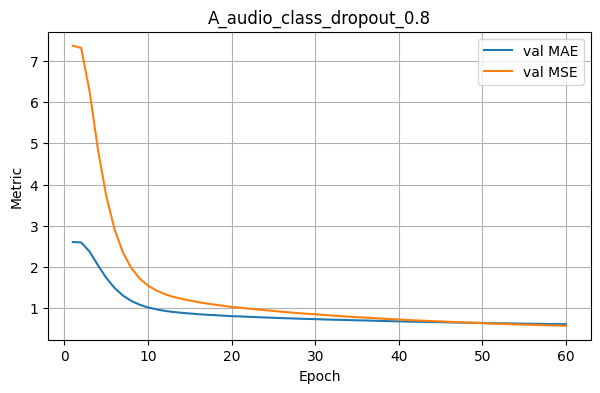

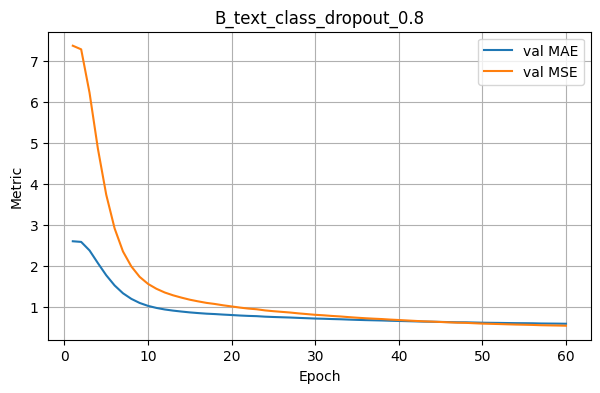

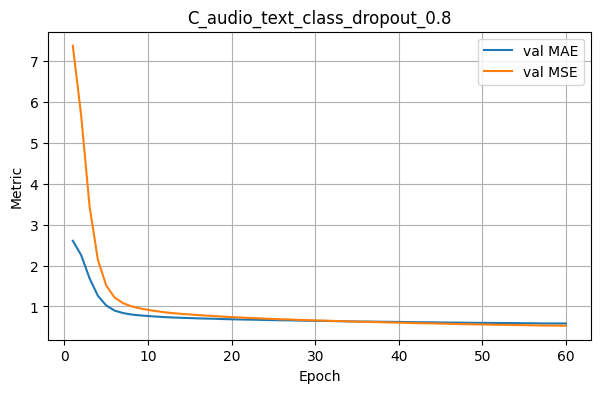

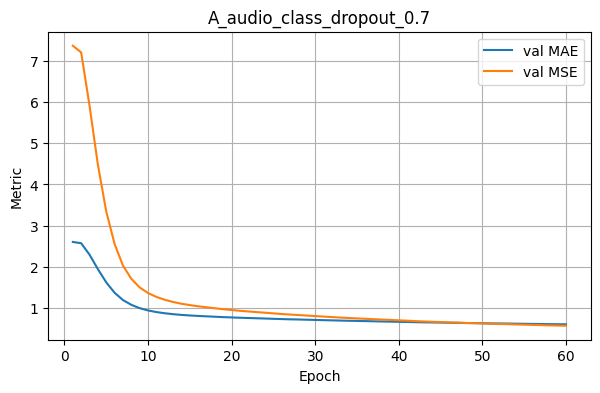

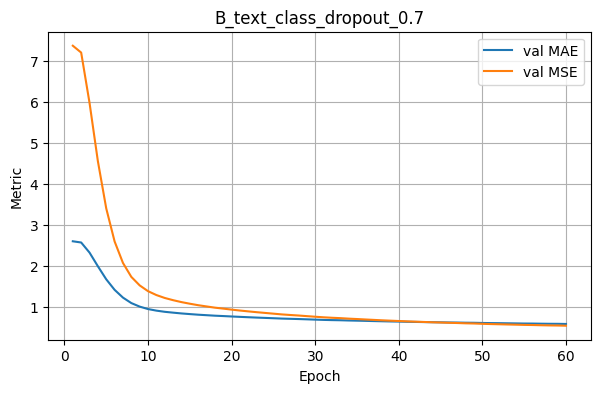

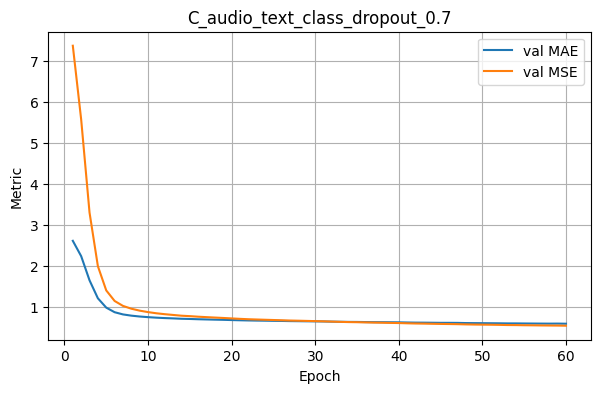

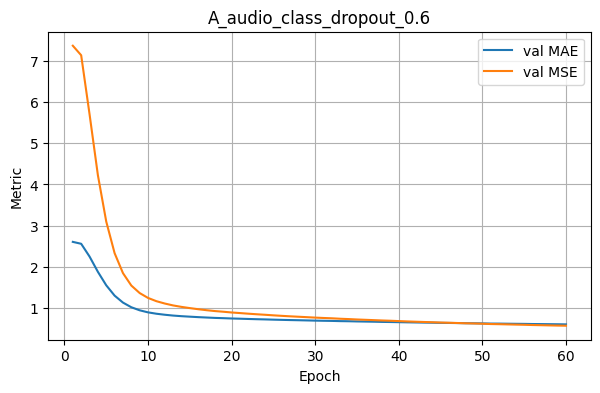

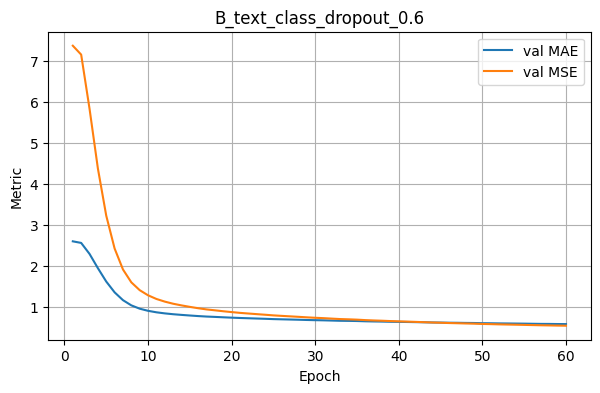

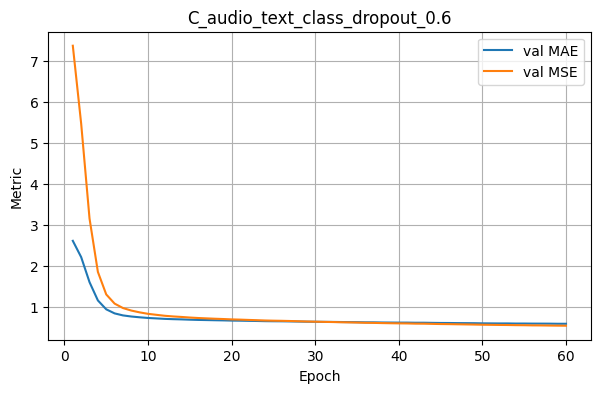

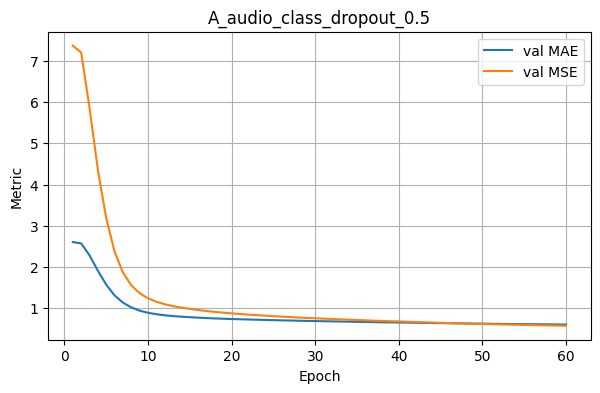

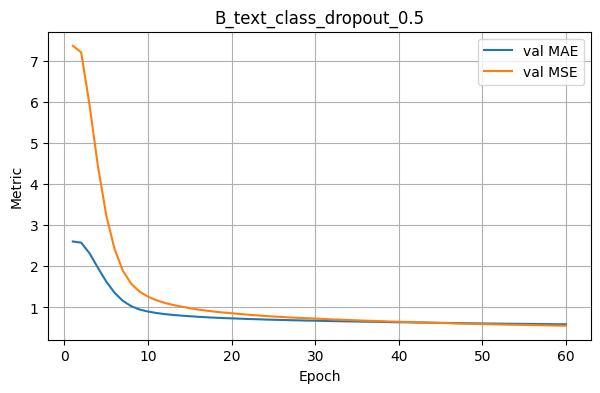

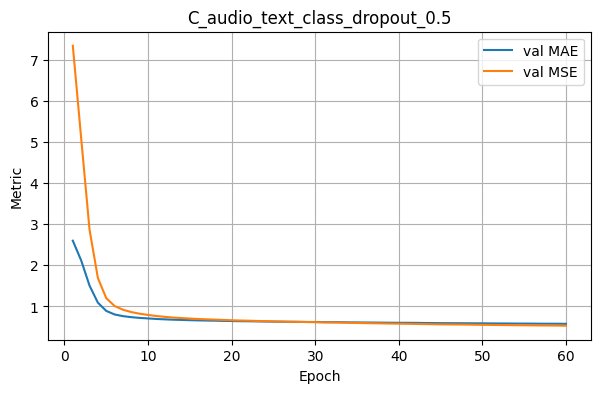

In [16]:
for exp_name, res in results.items():
    hist = res['history']
    plt.figure(figsize=(7, 4))
    plt.plot(hist['epoch'], hist['MAE'], label='val MAE')
    plt.plot(hist['epoch'], hist['MSE'], label='val MSE')
    plt.title(exp_name)
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.legend()
    plt.grid(True)
    plt.show()


Best experiment: C_audio_text_class_dropout_0.5


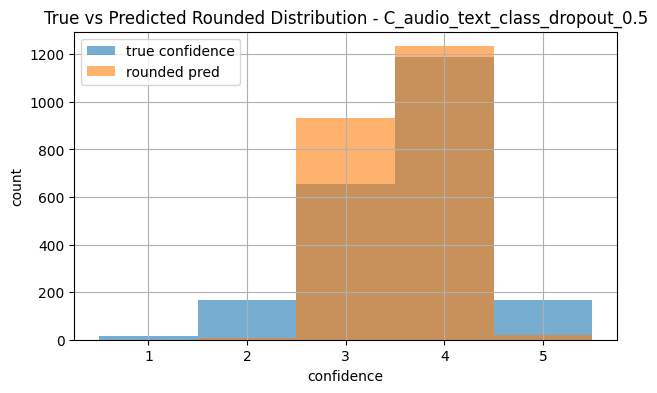

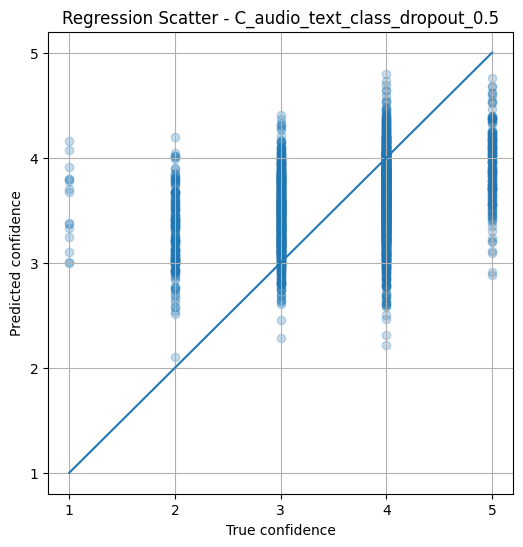

Confusion Matrix (counts, rounded regression output)
[[  0   0   7   8   0]
 [  0   1 118  47   0]
 [  0   2 364 290   0]
 [  0   4 426 749   9]
 [  0   0  19 139   9]]
Normalized Confusion Matrix (row-wise, 0~1)
[[0.     0.     0.4667 0.5333 0.    ]
 [0.     0.006  0.7108 0.2831 0.    ]
 [0.     0.003  0.5549 0.4421 0.    ]
 [0.     0.0034 0.3586 0.6305 0.0076]
 [0.     0.     0.1138 0.8323 0.0539]]


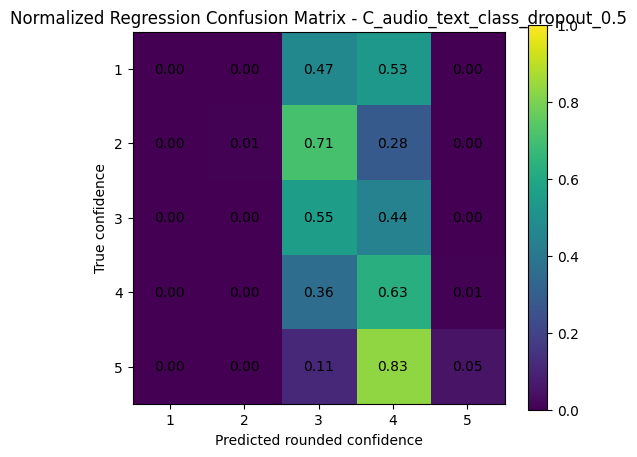

In [17]:
# =========================
# 13. 가장 좋은 실험의 예측 분포 / confusion matrix 확인
# =========================
best_exp = summary_df.iloc[0]['experiment']
best = results[best_exp]
print('Best experiment:', best_exp)

y_true = best['y_true'].astype(int)
y_pred = np.clip(best['y_pred'], 1, 5)
y_pred_round = best['y_pred_round'].astype(int)

plt.figure(figsize=(7, 4))
plt.hist(y_true, bins=np.arange(0.5, 6.5, 1), alpha=0.6, label='true confidence')
plt.hist(y_pred_round, bins=np.arange(0.5, 6.5, 1), alpha=0.6, label='rounded pred')
plt.xticks([1, 2, 3, 4, 5])
plt.title(f'True vs Predicted Rounded Distribution - {best_exp}')
plt.xlabel('confidence')
plt.ylabel('count')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.25)
plt.plot([1, 5], [1, 5])
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.xlabel('True confidence')
plt.ylabel('Predicted confidence')
plt.title(f'Regression Scatter - {best_exp}')
plt.grid(True)
plt.show()

cm = confusion_matrix(y_true, y_pred_round, labels=[1, 2, 3, 4, 5])
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
print("Confusion Matrix (counts, rounded regression output)")
print(cm)
print("Normalized Confusion Matrix (row-wise, 0~1)")
print(np.round(cm_norm, 4))

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, vmin=0, vmax=1)
plt.title(f"Normalized Regression Confusion Matrix - {best_exp}")
plt.xlabel("Predicted rounded confidence")
plt.ylabel("True confidence")
plt.xticks(range(5), [1, 2, 3, 4, 5])
plt.yticks(range(5), [1, 2, 3, 4, 5])
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")
plt.colorbar()
plt.show()

In [18]:
# =========================
# 14. C 실험 모델 저장 예시
# =========================
# 원하는 경우 target_base_exp를 수정해서 저장하세요.
import pickle

SAVE_DIR = OUTPUT_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

# C 실험 중 가장 좋은 dropout 결과 저장
target_base_exp = 'C_audio_text_class'
target_candidates = summary_df[summary_df['base_experiment'] == target_base_exp]
target_exp = target_candidates.iloc[0]['experiment'] if len(target_candidates) else summary_df.iloc[0]['experiment']
res = results[target_exp]

torch.save(res['model'].state_dict(), os.path.join(SAVE_DIR, f'{target_exp}_model.pt'))
with open(os.path.join(SAVE_DIR, 'class_label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

summary_df.to_csv(os.path.join(SAVE_DIR, 'experiment_summary_dropout_sweep.csv'), index=False)
print('Saved target experiment:', target_exp)
print('Saved to:', SAVE_DIR)

Saved target experiment: C_audio_text_class_dropout_0.5
Saved to: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_regression_outputs


## 해석 기준

- `C_audio_text_class`가 `A_audio_class`, `B_text_class`보다 좋으면 confidence가 audio/text 양쪽 정보와 class 매핑을 함께 반영한다는 뜻입니다.
- `A_audio_class`와 `B_text_class`의 차이는 confidence가 실제 음향 embedding 쪽에 더 민감한지, text embedding 쪽에 더 민감한지 비교하는 용도입니다.
- Accuracy는 regression 예측값을 반올림한 값이므로 보조 지표로만 보는 것이 좋습니다. 핵심 지표는 MAE와 MSE입니다.
- Confusion matrix는 regression output을 1~5로 clip 후 반올림한 값 기준이며, 그래프는 true class별 row-wise 0~1 정규화 값입니다.